# Lotto Model Evaluation

This notebook is dedicated to evaluation only.

It loads the saved experiment outputs produced by the modeling notebook and focuses on comparison, accuracy reporting, visualization, and interpretation.

### 1. Library Imports

In [9]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))

import json

import pandas as pd
import seaborn as sns

from src.config import (
    BACKTEST_RESULTS_FILE,
    BACKTEST_SUMMARY_FILE,
    HOLDOUT_DRAW_RESULTS_FILE,
    HOLDOUT_SUMMARY_FILE,
    MODEL_RUN_METADATA_FILE,
)
from src.visualization import (
    plot_backtest_metric_bars,
    plot_backtest_stability,
    plot_hit_distribution,
    plot_holdout_metric_bars,
)

sns.set_theme(style="whitegrid")

### 2. Load Saved Evaluation Artifacts

Run Notebook 05 first so these files exist.

In [10]:
holdout_summary = pd.read_csv(HOLDOUT_SUMMARY_FILE)
holdout_draw_results = pd.read_csv(HOLDOUT_DRAW_RESULTS_FILE)
backtest_results = pd.read_csv(BACKTEST_RESULTS_FILE)
backtest_summary = pd.read_csv(BACKTEST_SUMMARY_FILE)
run_metadata = json.loads(Path(MODEL_RUN_METADATA_FILE).read_text(encoding="utf-8"))

run_metadata

{'window': 20,
 'test_ratio': 0.2,
 'random_seed': 42,
 'holdout_model_names': ['freq_heuristic',
  'gap_heuristic',
  'random_baseline',
  'logistic_regression',
  'random_forest',
  'xgboost',
  'classifier_chain'],
 'backtest_model_names': ['freq_heuristic',
  'gap_heuristic',
  'random_baseline',
  'logistic_regression'],
 'include_backtest': True,
 'backtest_initial_train_size': 600,
 'backtest_test_size': 30,
 'backtest_step_size': 30,
 'max_backtest_folds': None,
 'n_rows': 1194,
 'n_train_rows': 955,
 'n_test_rows': 239}

### 3. Holdout Accuracy Table

This table reports model-level accuracy on the single holdout test split.

- `subset_accuracy`: strict exact-match accuracy over the 45-number one-hot target
- `number_level_accuracy`: average binary accuracy across all 45 number labels
- `avg_hit`: average overlap between the predicted six numbers and the actual six numbers

In [11]:
holdout_summary.sort_values(["avg_hit", "number_level_accuracy"], ascending=False)

,model,subset_accuracy,number_level_accuracy,avg_hit,hit_std
0,logistic_regression,0.0,0.772943,0.891213,0.846285
1,random_baseline,0.0,0.772571,0.882845,0.809772
2,classifier_chain,0.0,0.772571,0.882845,0.820041
3,xgboost,0.0,0.769410,0.811715,0.814428
4,freq_heuristic,0.0,0.767364,0.765690,0.762288
5,random_forest,0.0,0.766620,0.748954,0.830731
6,gap_heuristic,0.0,0.765132,0.715481,0.745005


### 4. Holdout Comparison Visualizations

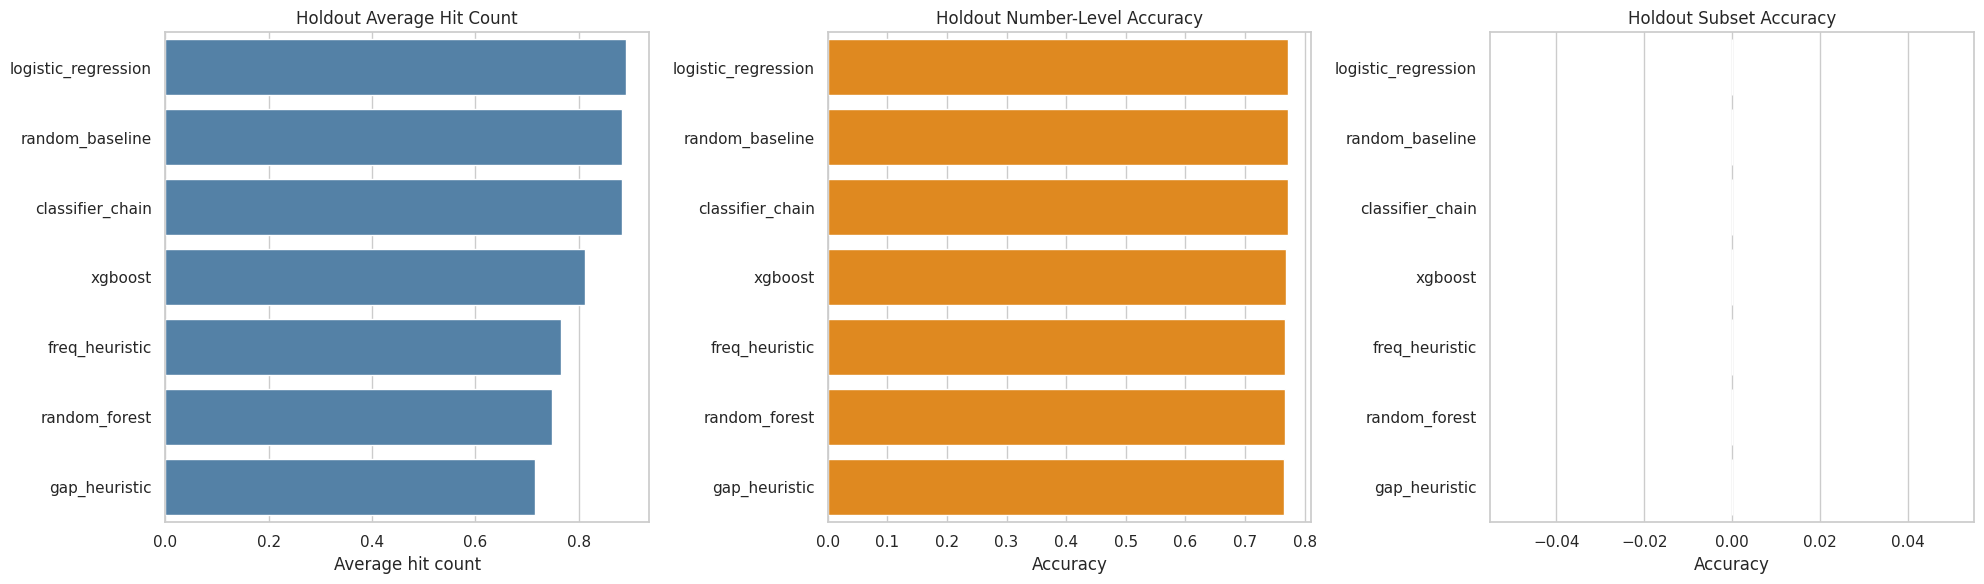

In [12]:
plot_holdout_metric_bars(holdout_summary)

### 5. Draw-Level Hit Distribution

This view shows how the per-draw hit counts are distributed across models.

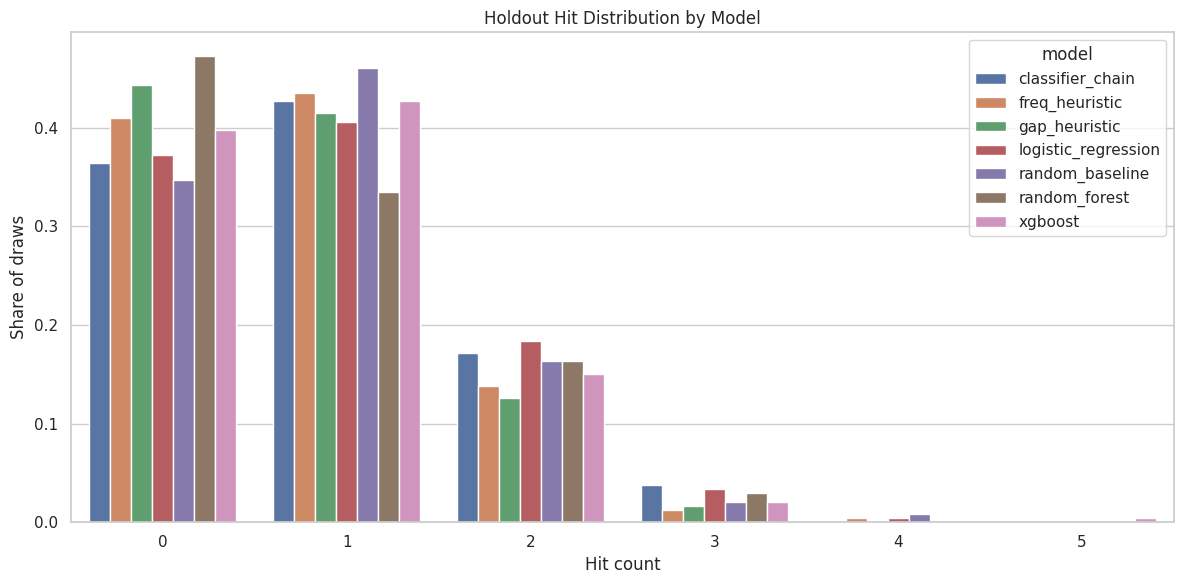

In [13]:
hit_distribution = (
    holdout_draw_results.groupby(["model", "hit_count"]).size().reset_index(name="count")
)
hit_distribution["share"] = hit_distribution.groupby("model")["count"].transform(lambda s: s / s.sum())

plot_hit_distribution(hit_distribution)

### 6. Rolling Backtest Summary

These results average performance across multiple expanding-window backtest folds.

In [14]:
backtest_summary.sort_values("mean_avg_hit", ascending=False)

,model,folds,mean_subset_accuracy,mean_number_level_accuracy,mean_avg_hit,std_avg_hit
0,random_baseline,19,0.0,0.772086,0.871930,0.150005
1,logistic_regression,19,0.0,0.771930,0.868421,0.156928
2,gap_heuristic,19,0.0,0.769123,0.805263,0.181986
3,freq_heuristic,19,0.0,0.768109,0.782456,0.141145


### 7. Rolling Backtest Visualizations

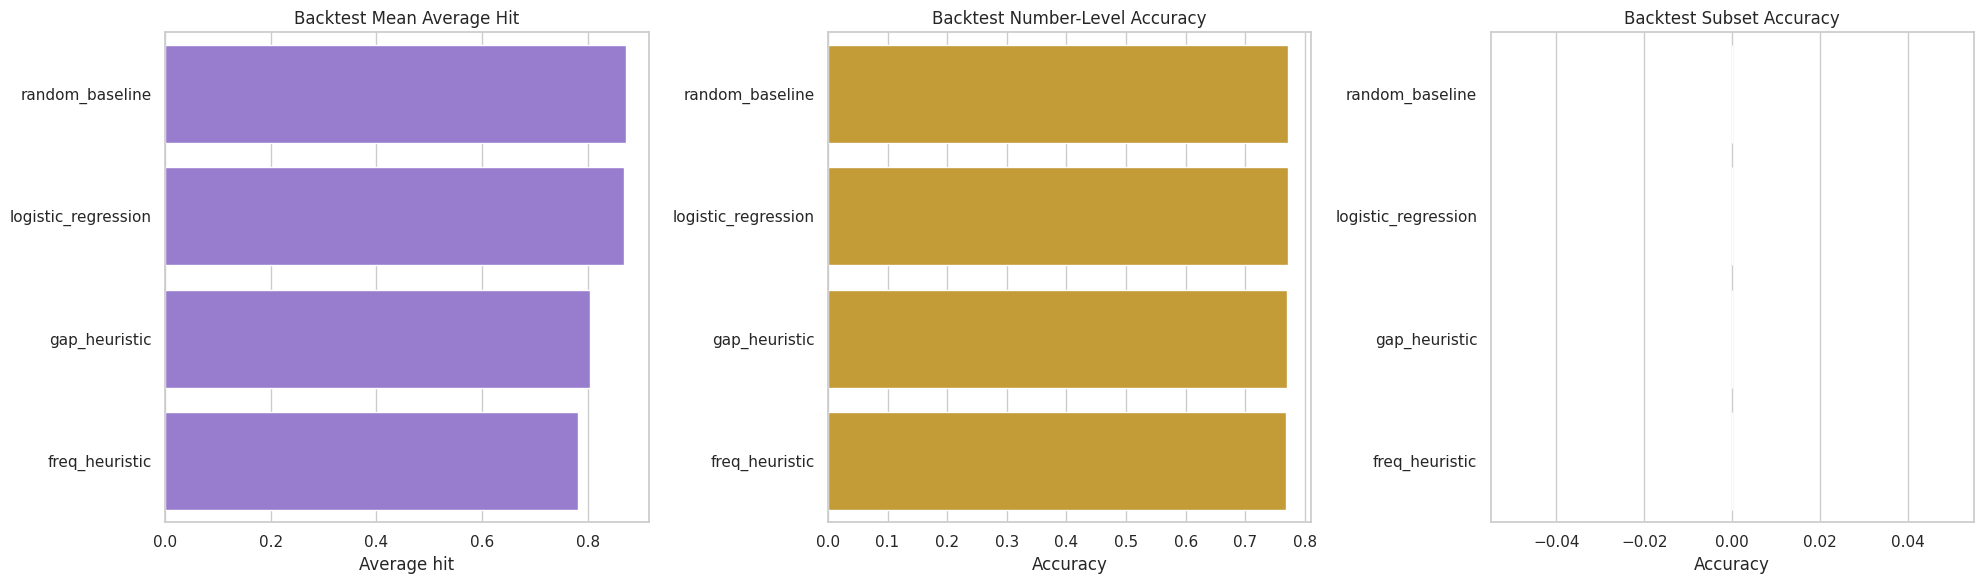

In [15]:
plot_backtest_metric_bars(backtest_summary)

### 8. Backtest Stability Over Folds

This line plot helps check whether model performance is stable or highly variable across time slices.

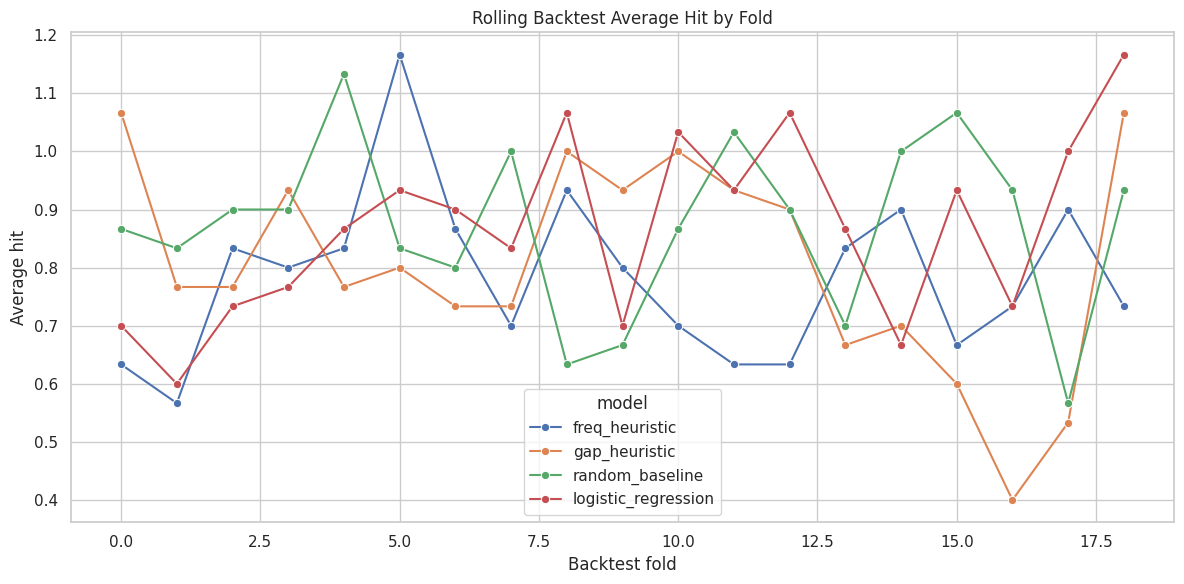

In [16]:
plot_backtest_stability(backtest_results)

### 9. Summary

This notebook evaluates the outputs produced by Notebook 05 without retraining the models.

The main outputs are:
- Holdout accuracy table for every model
- Draw-level hit distribution comparison
- Rolling backtest summary and stability plots

This split keeps Notebook 05 focused on model construction and Notebook 06 focused on interpretation and evaluation.